# Analysis of experiment #7: B&P

## Read data

In [1]:
# Read csv

import pandas as pd
import numpy as np

df = pd.read_csv("stats7.csv")

# Add column with edge probability
df["p"] = df.instance.apply(lambda s: float(s.split("_")[2][1:]))

# Add column with id of the instance
df["id"] = df.instance.apply(lambda s: int(s.split("_")[5][1:]))

# Remove final _ in solver name
df['solver'] = df['solver'].str.rstrip('_')

# Choose solvers to keep
df = df[df['solver'].isin(['byp', 'gurobi'])]

# Change solver name
df['solver'] = df['solver'].replace('byp', 'b&p')

# Format number of nodes for cplex
df.loc[(df.solver == 'cplex') & (df.nodes == 0), 'nodes'] = 1

# Unify TIME_EXCEEDED values
df = df.replace({'TIME_EXCEEDED_PR': 'TIME_EXCEEDED', 'TIME_EXCEEDED_LP': 'TIME_EXCEEDED'}) 

# Add column for each possible status
df["isOptimal"] = df.state == "OPTIMAL"
df["isInfeasible"] = df.state == "INFEASIBLE"
df["isFeasible"] = df.state == "TIME_EXCEEDED"

# Replace gap equal to -1 with NaN
df['gap'] = df['gap'].replace(-1, np.nan)

# Absolute gap
df['absGap'] = df.apply(lambda row: row.ub - row.lb if not np.isnan(row.gap) else np.nan, axis=1)
df['absGapRoot'] = df.apply(lambda row: row.initialHeurValue - row.rootlb if row.initialHeurValue > 0 else np.nan, axis=1)


# Remove the heuristic time from the total time
df.time = df.time - df.initialHeurTime

# Format timelimit
df.loc[df.state == 'TIME_EXCEEDED', 'time'] = 3600

# For cplex and gurobi, format initialHeurValue to -1 when it is 0
df.loc[(df.solver == 'cplex') & (df.initialHeurValue == 0), 'initialHeurValue'] = -1
df.loc[(df.solver == 'gurobi') & (df.initialHeurValue == 0), 'initialHeurValue'] = -1

print(list(df.columns))
df.head()

['instance', 'solver', 'run', 'nvertices', 'nedges', 'nP', 'nQ', 'nvars', 'ncons', 'state', 'terminationReason', 'time', 'nodes', 'nodesLeft', 'lb', 'ub', 'gap', 'initialHeurValue', 'initialHeurTime', 'initialSemigreedyIters', 'nNodesInt', 'nNodesFrac', 'nNodesGcp', 'nNodesTrivial', 'nNodesInfeas', 'nNodesInfeasPrepro', 'nNodesInfeasCheck', 'nNodesInfeasAux', 'gcpAvgTime', 'nsol', 'nsolHeur', 'nsolLR', 'nsolGCP', 'nsolTrivial', 'ninitSol', 'ninitDummy', 'ninit', 'rootNVertices', 'rootNEdges', 'rootNP', 'rootNQ', 'rootlb', 'rootub', 'rootHeurTime', 'rootFeasTime', 'rootCgTime', 'rootNCalls', 'rootNCallsPool', 'rootNCallsHeur', 'rootNCallsMwis1', 'rootNCallsMwis2', 'rootNCallsExact', 'rootNCols', 'rootNColsPool', 'rootNColsHeur', 'rootNColsMwis1', 'rootNColsMwis2', 'rootNColsExact', 'rootTime', 'rootTimePool', 'rootTimeHeur', 'rootTimeMwis1', 'rootTimeMwis2', 'rootTimeExact', 'otherNodesHeurTime', 'otherNodesFeasNCalls', 'otherNodesFeasTime', 'otherNodesNCalls', 'otherNodesNCallsPool', '

,instance,solver,run,nvertices,nedges,nP,nQ,nvars,ncons,state,...,otherNodesTimeMwis1,otherNodesTimeMwis2,otherNodesTimeExact,p,id,isOptimal,isInfeasible,isFeasible,absGap,absGapRoot
0,r_n110_p0.25_nA22_nB22_i2,b&p,0,110,1525,22,22,-1,-1,OPTIMAL,...,0.076809,0.058787,4.01747,0.25,2,True,False,False,0.0,1.36966
1,r_n110_p0.25_nA33_nB22_i1,gurobi,0,110,1531,33,22,428,11605,OPTIMAL,...,0.000000,0.000000,0.00000,0.25,1,True,False,False,0.0,5.00000
3,r_n110_p0.5_nA33_nB33_i0,b&p,0,110,2963,33,33,-1,-1,OPTIMAL,...,0.034163,0.033727,5.26109,0.50,0,True,False,False,0.0,1.33718
4,r_n110_p0.25_nA22_nB33_i2,b&p,0,110,1500,22,33,-1,-1,OPTIMAL,...,0.000000,0.000000,0.00000,0.25,2,True,False,False,0.0,0.43662
5,r_n110_p0.5_nA22_nB22_i2,gurobi,0,110,2994,22,22,444,19202,OPTIMAL,...,0.000000,0.000000,0.00000,0.50,2,True,False,False,0.0,5.00000


## Summary

<Axes: >

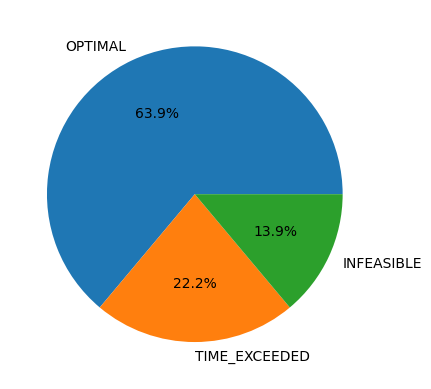

In [2]:
df[df.solver=="b&p"].state.value_counts().plot.pie(autopct='%1.1f%%')

<Axes: >

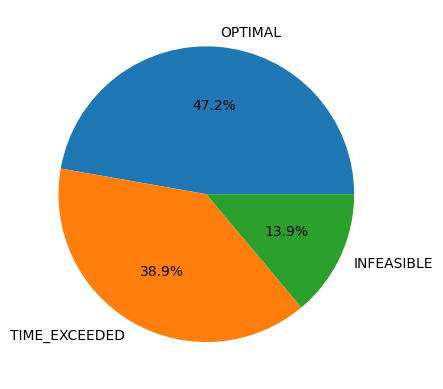

In [3]:
df[df.solver=="gurobi"].state.value_counts().plot.pie(autopct='%1.1f%%')

In [4]:
df_avg = df.groupby(["p","solver"]).agg(
    {
        "isOptimal": "sum",
        "isInfeasible": "sum",
        "isFeasible": "sum",
        "time": "mean",
        "absGap": "mean",
    }
).reset_index()

columns = [("p", ""), ("solver", ""), ("# status", "opt"), 
           ("# status", "infeas"), ("# status", "tilim"), ("time (s)",""), ("abs gap", "")]
df_avg.columns = pd.MultiIndex.from_tuples(columns)
df_avg[("time (s)", "")] = df_avg[("time (s)", "")].astype(int)
df_avg[("abs gap", "")] = df_avg[("abs gap", "")].round(2)
df_avg

p  solver # status              time (s) abs gap
                     opt infeas tilim                 
0  0.25     b&p        7      1     4     1281    0.36
1  0.25  gurobi       11      1     0        8    0.00
2  0.50     b&p        8      2     2     1275    0.20
3  0.50  gurobi        5      2     5     1580    0.60
4  0.75     b&p        8      2     2      763    0.20
5  0.75  gurobi        1      2     9     2867    2.70

In [5]:
df_avg.to_latex("table7-1.tex", index=False, float_format="%.1f", na_rep="--")

In [6]:
df_avg = df.groupby(["nP","nQ","solver"]).agg(
    {
        "isOptimal": "sum",
        "isInfeasible": "sum",
        "isFeasible": "sum",
        "time": "mean",
        "absGap": "mean",
    }
).reset_index()

columns = [("n", ""), ("m", ""), ("solver", ""), ("# status", "opt"), 
           ("# status", "infeas"), ("# status", "tilim"), ("time (s)", ""), ("abs gap", "")]
df_avg.columns = pd.MultiIndex.from_tuples(columns)
df_avg[("time (s)", "")] = df_avg[("time (s)", "")].astype(int)
df_avg[("abs gap", "")] = df_avg[("abs gap", "")].round(2)
df_avg

n   m  solver # status              time (s) abs gap
                       opt infeas tilim                 
0  22  22     b&p        7      2     0      287    0.00
1  22  22  gurobi        5      2     2      874    0.43
2  22  33     b&p        9      0     0      314    0.00
3  22  33  gurobi        7      0     2     1056    0.22
4  33  22     b&p        3      3     3     1475    0.50
5  33  22  gurobi        2      3     4     1609    2.17
6  33  33     b&p        4      0     5     2349    0.56
7  33  33  gurobi        3      0     6     2401    1.67

In [7]:
df_avg.to_latex("table7-2.tex", index=False, float_format="%.1f", na_rep="--")

## Infeasible instances

In [8]:
df_inf = df[df.state == "INFEASIBLE"]
df_inf = df_inf.sort_values(['nvertices', 'p', 'nP', 'nQ']).reset_index(drop=True)

In [9]:
df_inf2 = df_inf[['nvertices', 'p', 'nP', 'nQ', 'state', 'nodes', 'nNodesFrac', 'nNodesInt', 'nNodesGcp', 'nNodesTrivial', 'nNodesInfeas',
           'time', 'nNodesInfeas', 'nNodesInfeasPrepro', 'nNodesInfeasCheck', 'nNodesInfeasAux']]
columns = [('N','',''), ('p','',''), ('n','',''), ('m','',''), ('status','',''), ('nodes','total',''), ('nodes','frac',''), 
           ('nodes','int',''), ('nodes','gcp',''), ('nodes','trivial',''), ('nodes','infeas',''), 
           ('time (s)','',''), ('infeasible nodes','total',''), ('infeasible nodes','prepro',''), ('infeasible nodes','check',''), ('infeasible nodes','aux','')]
df_inf2.columns = pd.MultiIndex.from_tuples(columns)
df_inf2[('nodes','infeas','')] = df_inf2[('nodes','infeas','')].round(0).astype(int)
df_inf2[('infeasible nodes','total','')] = df_inf2[('infeasible nodes','total','')].round(0).astype(int)
df_inf2

N     p   n   m      status nodes                              time (s)  \
                                 total frac int gcp trivial infeas             
                                                                               
0  110  0.25  33  22  INFEASIBLE     1    0   0   0       0      1  0.000387   
1  110  0.25  33  22  INFEASIBLE     0    0   0   0       0      0  0.000309   
2  110  0.50  22  22  INFEASIBLE     1    0   0   0       0      1  0.000668   
3  110  0.50  22  22  INFEASIBLE     0    0   0   0       0      0  0.000582   
4  110  0.50  33  22  INFEASIBLE     0    0   0   0       0      0  0.000673   
5  110  0.50  33  22  INFEASIBLE     1    0   0   0       0      1  0.000732   
6  110  0.75  22  22  INFEASIBLE     1    0   0   0       0      1  0.001103   
7  110  0.75  22  22  INFEASIBLE     0    0   0   0       0      0  0.000999   
8  110  0.75  33  22  INFEASIBLE     1    0   0   0       0      1  0.001165   
9  110  0.75  33  22  INFEASIBLE     0    0   0   0       0      0  0.001106   

  infeasible nodes                   
             total prepro check aux  
                                     
0                1      1     0   0  
1                0      0     0   0  
2                1      1     0   0  
3                0      0     0   0  
4                0      0     0   0  
5                1      1     0   0  
6                1      1     0   0  
7                0      0     0   0  
8                1      1     0   0  
9                0      0     0   0

## Initialization

In [10]:
df2 = df[(df.solver == "b&p") & ((df.state == "OPTIMAL") | (df.state == "TIME_EXCEEDED"))]
print("Total number of nodes initialized with a heuristic solution:", df2['ninit'].sum())
print("Total number of nodes initialized with a dummy column:", df2['ninitDummy'].sum())
print("Total number of infeasible nodes:", df2['nNodesInfeas'].sum())

Total number of nodes initialized with a heuristic solution: 8888
Total number of nodes initialized with a dummy column: 334
Total number of infeasible nodes: 3.0


## Optimal or feasible instances

In [12]:
# select optimal and time exceeded instances
df2 = df[(df.state == "OPTIMAL") | (df.state == "TIME_EXCEEDED")]

# pivot table by solver
df2 = df2.pivot_table(index=["instance","p", "nP", "nQ", "id", "initialHeurValue"], 
                     columns="solver", 
                     values=["time", "nodes", "rootlb", "lb", "ub", "rootTime", "otherNodesTime", "rootNCols", "otherNodesNCols"],
                     ).reset_index()
print(list(df2.columns))
df2.head()

[('instance', ''), ('p', ''), ('nP', ''), ('nQ', ''), ('id', ''), ('initialHeurValue', ''), ('lb', 'b&p'), ('lb', 'gurobi'), ('nodes', 'b&p'), ('nodes', 'gurobi'), ('otherNodesNCols', 'b&p'), ('otherNodesNCols', 'gurobi'), ('otherNodesTime', 'b&p'), ('otherNodesTime', 'gurobi'), ('rootNCols', 'b&p'), ('rootNCols', 'gurobi'), ('rootTime', 'b&p'), ('rootTime', 'gurobi'), ('rootlb', 'b&p'), ('rootlb', 'gurobi'), ('time', 'b&p'), ('time', 'gurobi'), ('ub', 'b&p'), ('ub', 'gurobi')]


instance     p  nP  nQ id initialHeurValue   lb  \
solver                                                               b&p   
0       r_n110_p0.25_nA22_nB22_i0  0.25  22  22  0              2.0  2.0   
1       r_n110_p0.25_nA22_nB22_i1  0.25  22  22  1              2.0  2.0   
2       r_n110_p0.25_nA22_nB22_i2  0.25  22  22  2              3.0  2.0   
3       r_n110_p0.25_nA22_nB33_i0  0.25  22  33  0              2.0  2.0   
4       r_n110_p0.25_nA22_nB33_i1  0.25  22  33  1              2.0  2.0   

               nodes         ... rootNCols         rootTime          rootlb  \
solver gurobi    b&p gurobi  ...       b&p gurobi       b&p gurobi      b&p   
0         2.0    1.0    0.0  ...     420.0    0.0   6.55589    0.0  1.65367   
1         2.0    1.0    1.0  ...     474.0    0.0  34.85140    0.0  1.50984   
2         2.0  193.0    1.0  ...     505.0    0.0  12.87560    0.0  1.63034   
3         2.0    1.0    0.0  ...     460.0    0.0   9.13549    0.0  1.56547   
4         2.0    1.0    0.0  ...     475.0    0.0   1.93819    0.0  1.56059   

                    time            ub         
solver gurobi        b&p   gurobi  b&p gurobi  
0        -1.0    6.57696  0.04426  2.0    2.0  
1        -1.0   34.88421  0.18710  2.0    2.0  
2        -1.0  833.14971  0.57366  2.0    2.0  
3        -1.0    9.16220  0.04492  2.0    2.0  
4        -1.0    1.96290  0.04202  2.0    2.0  

[5 rows x 24 columns]

In [13]:
# sort columns: first b&p columns, then gurobi columns
# avoid pricing columns for gurobi
df3 = df2[[('instance', ''),('p', ''), ('nP', ''), ('nQ', ''), ('initialHeurValue', ''),
           ('time', 'b&p'), ('nodes', 'b&p'), ('rootlb', 'b&p'), ('lb', 'b&p'), ('ub', 'b&p'), ('rootTime', 'b&p'), ('otherNodesTime', 'b&p'), ('rootNCols', 'b&p'), ('otherNodesNCols', 'b&p'),
           ('time', 'gurobi'), ('nodes', 'gurobi'), ('lb', 'gurobi'), ('ub', 'gurobi')]]

# rename columns with multilevel index
df3.columns = pd.MultiIndex.from_tuples([('instance', '', ''), ('p', '', ''), ('n', '', ''), ('m', '', ''), ('hval', '', ''), 
                                         ('b&p', 'time (s)', ''), ('b&p', 'nodes', ''), ('b&p', 'rval', ''), ('b&p', 'lb', ''), ('b&p', 'ub', ''),
                                         ('b&p', 'pricing time (s)', 'root'), ('b&p', 'pricing time (s)', 'non-root'), ('b&p', '#added cols', 'root'), ('b&p', '#added cols', 'non-root'),
                                         ('gurobi', 'time (s)', ''), ('gurobi', 'nodes', ''), ('gurobi', 'lb', ''), ('gurobi', 'ub', '')])

# format
df3[('hval', '', '')] = df3[('hval', '', '')].astype(int)
df3[('b&p', 'time (s)', '')] = df3[('b&p', 'time (s)', '')].apply(lambda x: "{:.1f}".format(x) if x < 3600 else "tilim")
df3[('b&p', 'nodes', '')] = df3[('b&p', 'nodes', '')].astype(int)
df3[('b&p', 'rval', '')] = df3[('b&p', 'rval', '')].round(2)
df3[('b&p', 'lb', '')] = df3[('b&p', 'lb', '')].round(2)
df3[('b&p', 'ub', '')] = df3[('b&p', 'ub', '')].astype(int)
df3[('b&p', 'pricing time (s)', 'root')] = df3[('b&p', 'pricing time (s)', 'root')].round(1)
df3[('b&p', 'pricing time (s)', 'non-root')] = df3[('b&p', 'pricing time (s)', 'non-root')].apply(lambda x: "{:.1f}".format(x) if x > 0 else "--")
df3[('b&p', '#added cols', 'root')] = df3[('b&p', '#added cols', 'root')].astype(int)
df3[('b&p', '#added cols', 'non-root')] = df3[('b&p', '#added cols', 'non-root')].apply(lambda x: str(int(x)) if x > 0 else "--")

df3[('gurobi', 'time (s)', '')] = df3[('gurobi', 'time (s)', '')].apply(lambda x: "{:.2f}".format(x) if x < 3600 else "tilim")
df3[('gurobi', 'nodes', '')] = df3[('gurobi', 'nodes', '')].astype(int)
df3[('gurobi', 'lb', '')] = df3[('gurobi', 'lb', '')].round(2)
df3[('gurobi', 'ub', '')] = df3[('gurobi', 'ub', '')].astype(int)

df3[('hval','','')] = df3[('hval','','')].apply(lambda x: str(x) if x > 0 else "--")

print(list(df3.columns))
df3

[('instance', '', ''), ('p', '', ''), ('n', '', ''), ('m', '', ''), ('hval', '', ''), ('b&p', 'time (s)', ''), ('b&p', 'nodes', ''), ('b&p', 'rval', ''), ('b&p', 'lb', ''), ('b&p', 'ub', ''), ('b&p', 'pricing time (s)', 'root'), ('b&p', 'pricing time (s)', 'non-root'), ('b&p', '#added cols', 'root'), ('b&p', '#added cols', 'non-root'), ('gurobi', 'time (s)', ''), ('gurobi', 'nodes', ''), ('gurobi', 'lb', ''), ('gurobi', 'ub', '')]


instance     p   n   m hval      b&p                     \
                                                 time (s) nodes   rval    lb   
                                                                               
0   r_n110_p0.25_nA22_nB22_i0  0.25  22  22    2      6.6     1   1.65   2.0   
1   r_n110_p0.25_nA22_nB22_i1  0.25  22  22    2     34.9     1   1.51   2.0   
2   r_n110_p0.25_nA22_nB22_i2  0.25  22  22    3    833.1   193   1.63   2.0   
3   r_n110_p0.25_nA22_nB33_i0  0.25  22  33    2      9.2     1   1.57   2.0   
4   r_n110_p0.25_nA22_nB33_i1  0.25  22  33    2      2.0     1   1.56   2.0   
5   r_n110_p0.25_nA22_nB33_i2  0.25  22  33    2      9.5     1   1.56   2.0   
6   r_n110_p0.25_nA33_nB22_i1  0.25  33  22    4    tilim   234   2.60   3.0   
7   r_n110_p0.25_nA33_nB22_i2  0.25  33  22    4    tilim   119   2.64   3.0   
8   r_n110_p0.25_nA33_nB33_i0  0.25  33  33    4    tilim   363   2.56   3.0   
9   r_n110_p0.25_nA33_nB33_i1  0.25  33  33    3     77.8     1   2.39   3.0   
10  r_n110_p0.25_nA33_nB33_i2  0.25  33  33    4    tilim   304   2.54   3.0   
11   r_n110_p0.5_nA22_nB22_i1  0.50  22  22    4    765.6    97   2.81   4.0   
12   r_n110_p0.5_nA22_nB22_i2  0.50  22  22    4    503.8    41   2.87   4.0   
13   r_n110_p0.5_nA22_nB33_i0  0.50  22  33    4     91.5    35   2.89   4.0   
14   r_n110_p0.5_nA22_nB33_i1  0.50  22  33    4    899.9   359   2.75   4.0   
15   r_n110_p0.5_nA22_nB33_i2  0.50  22  33    4   1216.1   419   2.72   3.0   
16   r_n110_p0.5_nA33_nB22_i1  0.50  33  22    7   2114.4   349   5.24   6.0   
17   r_n110_p0.5_nA33_nB22_i2  0.50  33  22    7    tilim   259   5.23   6.0   
18   r_n110_p0.5_nA33_nB33_i0  0.50  33  33    6   1326.7   243   4.66   6.0   
19   r_n110_p0.5_nA33_nB33_i1  0.50  33  33    6    tilim   466   4.62   5.0   
20   r_n110_p0.5_nA33_nB33_i2  0.50  33  33    6   1190.7   217   4.66   6.0   
21  r_n110_p0.75_nA22_nB22_i1  0.75  22  22    6    155.9    47   4.76   6.0   
22  r_n110_p0.75_nA22_nB22_i2  0.75  22  22    6    288.2    57   4.77   6.0   
23  r_n110_p0.75_nA22_nB33_i0  0.75  22  33    6    236.6   145   4.72   6.0   
24  r_n110_p0.75_nA22_nB33_i1  0.75  22  33    6    145.1    69   4.64   5.0   
25  r_n110_p0.75_nA22_nB33_i2  0.75  22  33    6    219.5   115   4.60   5.0   
26  r_n110_p0.75_nA33_nB22_i1  0.75  33  22   --     18.3    15  10.85  12.0   
27  r_n110_p0.75_nA33_nB22_i2  0.75  33  22   12    346.4    71   9.74  11.0   
28  r_n110_p0.75_nA33_nB33_i0  0.75  33  33   10    tilim  2465   8.05   9.0   
29  r_n110_p0.75_nA33_nB33_i1  0.75  33  33   10    tilim  1918   8.04   9.0   
30  r_n110_p0.75_nA33_nB33_i2  0.75  33  33   10    546.1   275   8.22   9.0   

                                                        gurobi               \
    ub pricing time (s)          #added cols          time (s)   nodes   lb   
                   root non-root        root non-root                         
0    2              6.6       --         420       --     0.04       0  2.0   
1    2             34.9       --         474       --     0.19       1  2.0   
2    2             12.9      4.3         505      100     0.57       1  2.0   
3    2              9.1       --         460       --     0.04       0  2.0   
4    2              1.9       --         475       --     0.04       0  2.0   
5    2              9.5       --         455       --     0.10       1  2.0   
6    4             39.3     15.2         802      166    10.39     667  3.0   
7    4             78.9     29.7         844      168    74.98    5804  4.0   
8    4             31.1      9.8         733      148     2.76     569  3.0   
9    3             77.7       --         776       --     1.68       4  3.0   
10   4             40.4     11.7         686      144     9.92     652  3.0   
11   4             21.5      7.7         384       78   522.92   39595  4.0   
12   4             25.6     11.9         373       77   145.03    4964  4.0   
13   4              9.5      2.4    

In [15]:
df3.to_latex("table7-3.tex", index=False, float_format="%.1f", na_rep="--")

In [27]:
df4 = df[(df.solver == "b&p") & ((df.state == "OPTIMAL") | (df.state == "TIME_EXCEEDED"))]

print("Root: total pricing time:", df4['rootTime'].mean())
print("Root: exact pricing time:", df4['rootTimeExact'].mean())
print("Root: percentage of the total time spent by exact pricing:", df4['rootTimeExact'].mean() / df4['rootTime'].mean() * 100, "%")

print("Other nodes: average pricing time:", df4['otherNodesTime'].mean())
print("Other nodes: average exact pricing time:", df4['otherNodesTimeExact'].mean())
print("Other nodes: percentage of the total time spent by exact pricing:", df4['otherNodesTimeExact'].mean() / df4['otherNodesTime'].mean() * 100, "%")

Root: total pricing time: 20.984634516129034
Root: exact pricing time: 20.315584193548393
Root: percentage of the total time spent by exact pricing: 96.81171324634508 %
Other nodes: average pricing time: 5.173412870967742
Other nodes: average exact pricing time: 5.043063516129032
Other nodes: percentage of the total time spent by exact pricing: 97.48039914675654 %
